In [25]:
# Importing libraries
import pandas as pd
from pathlib import Path
import os
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

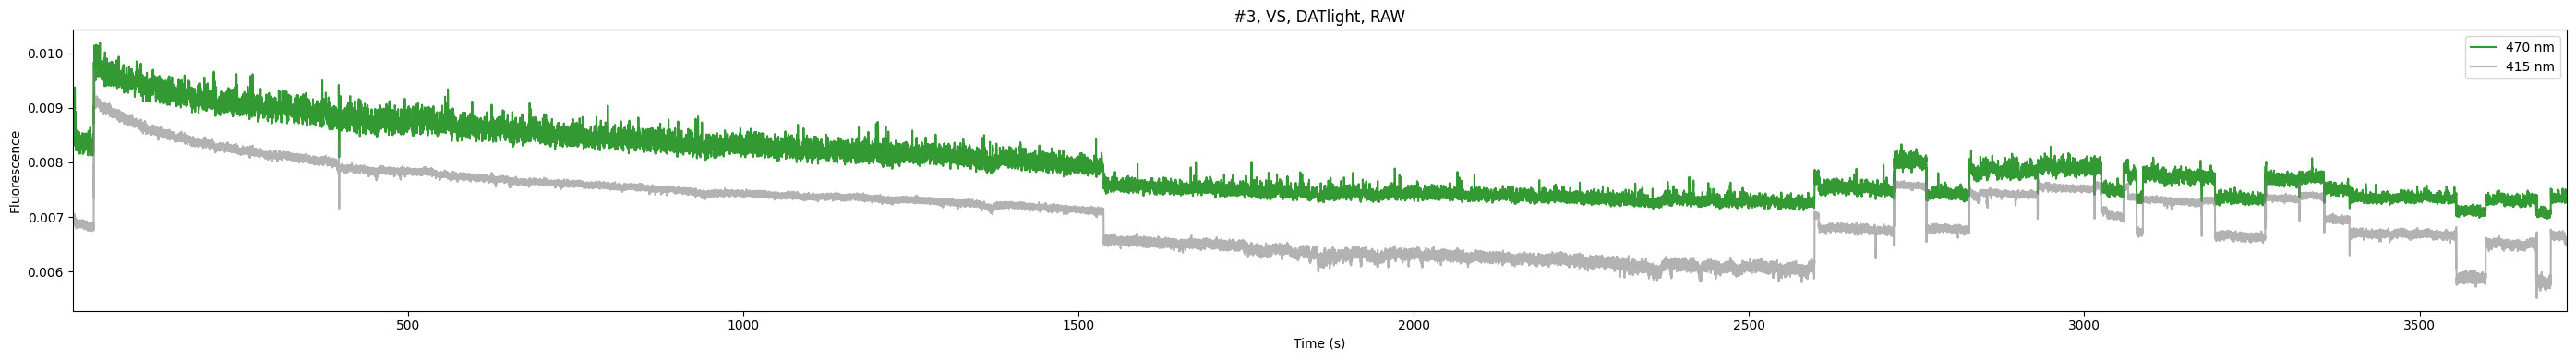

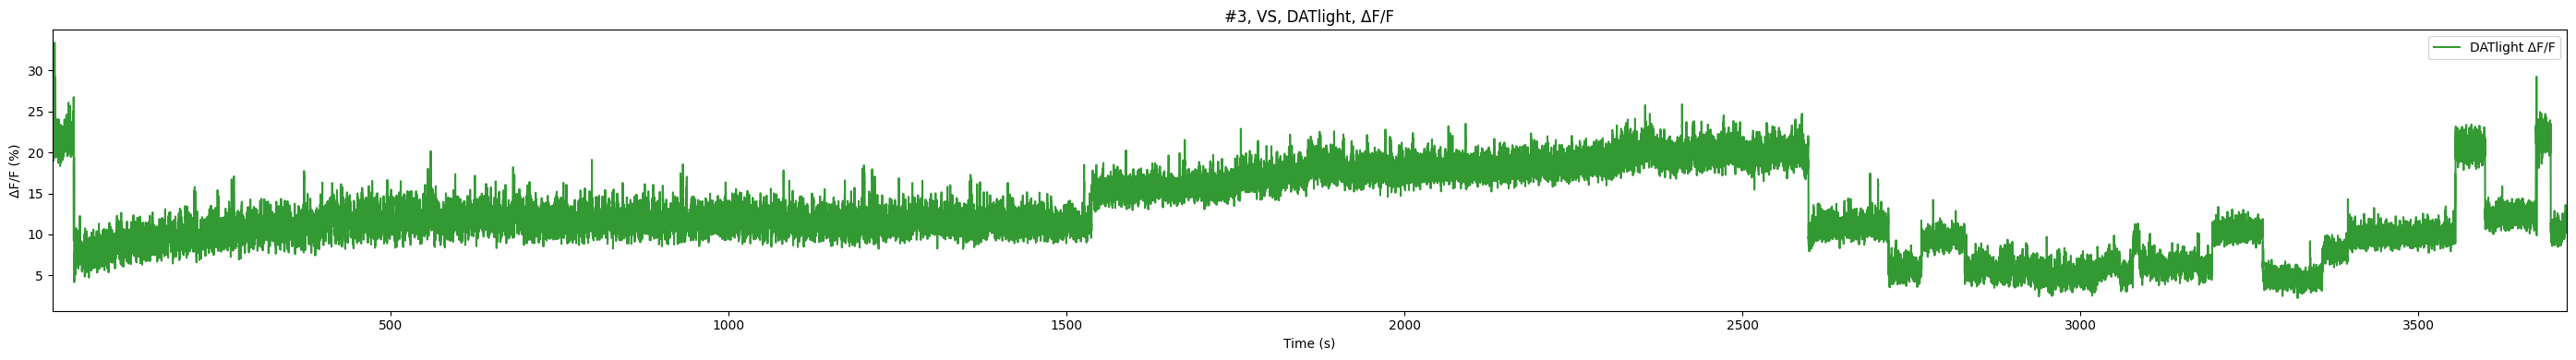

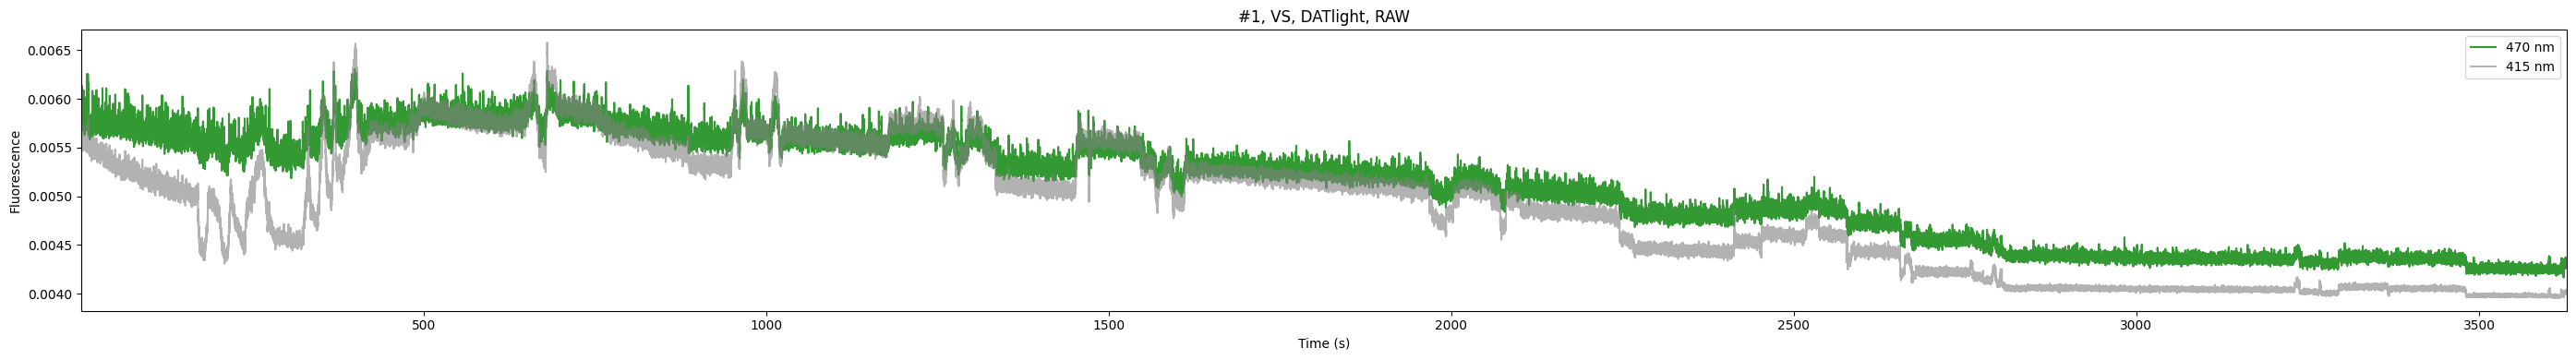

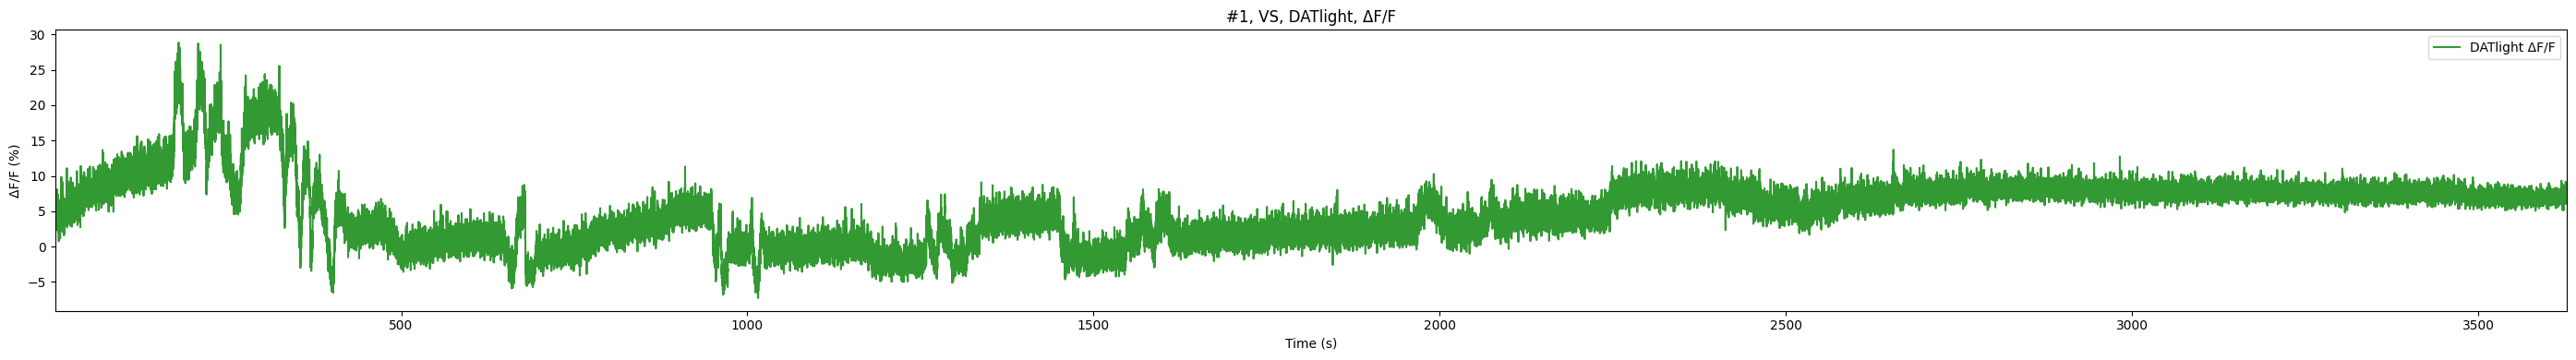

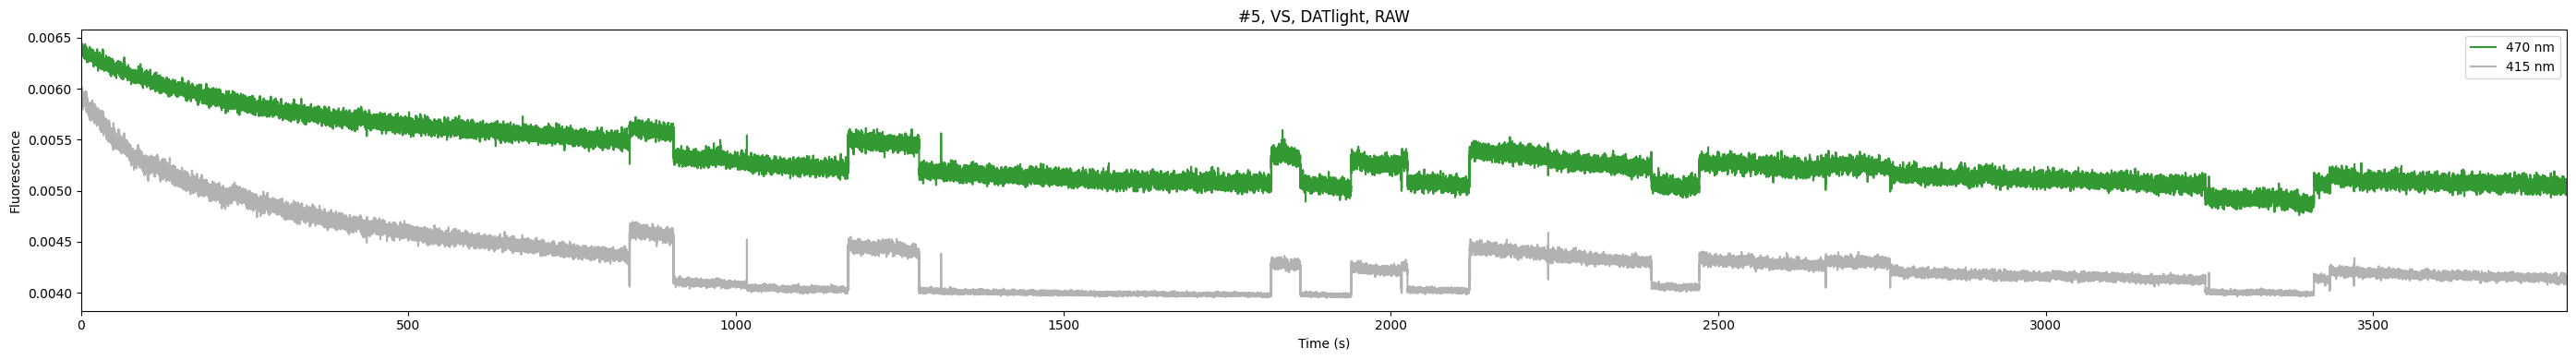

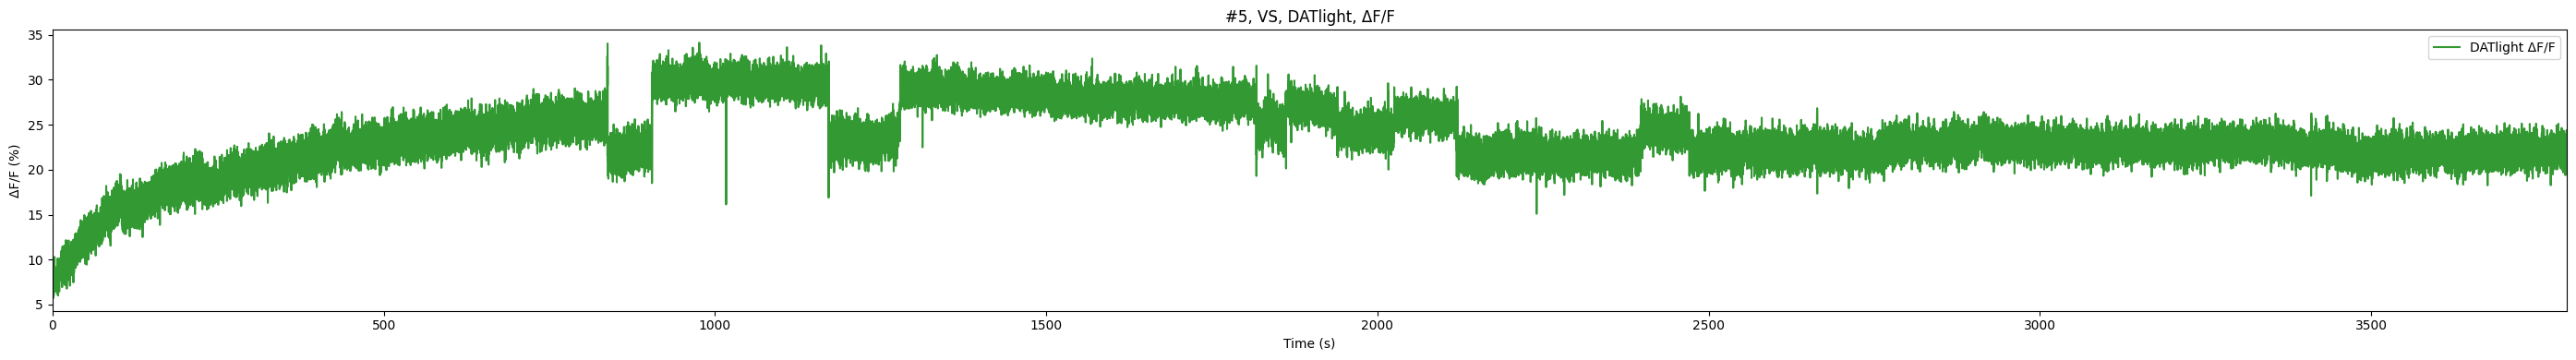

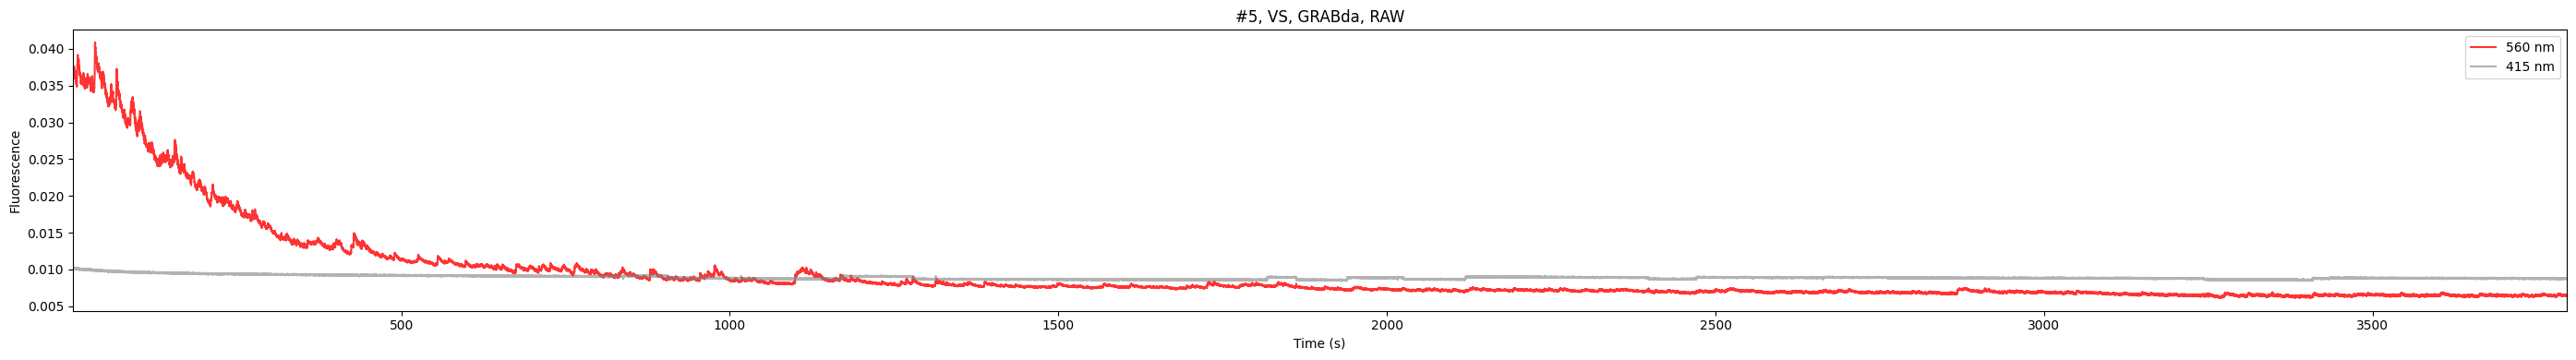

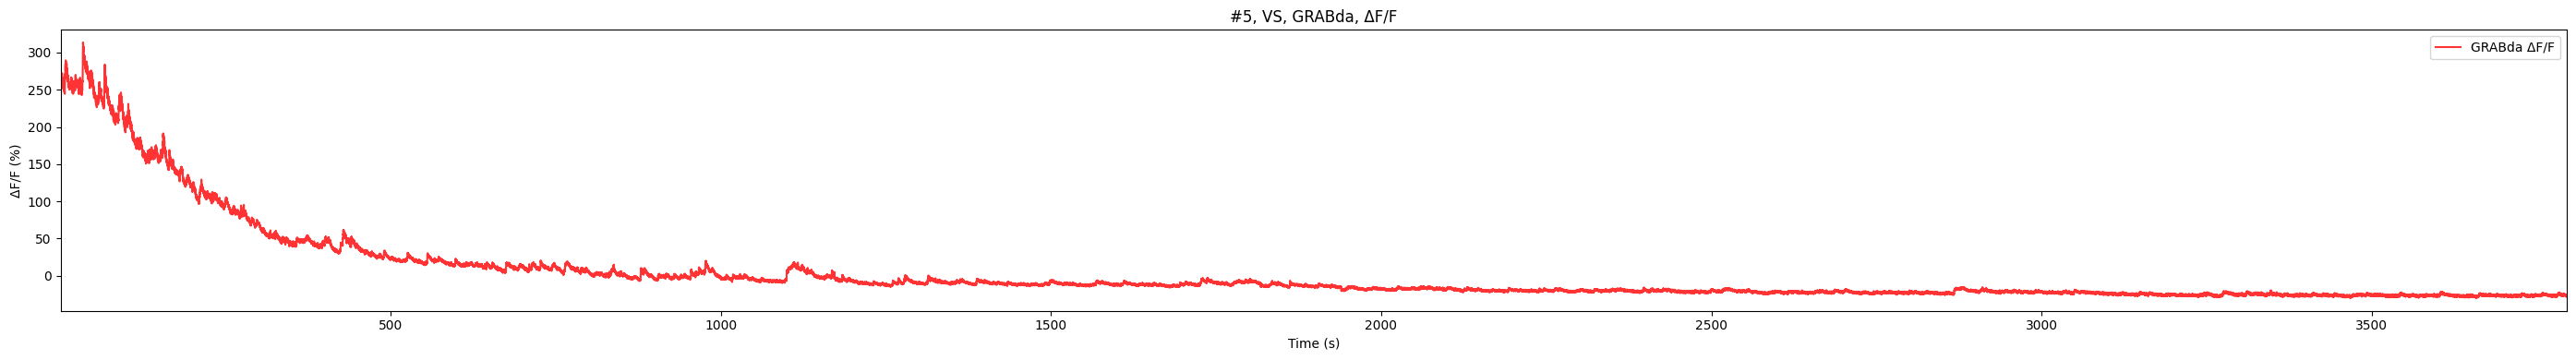

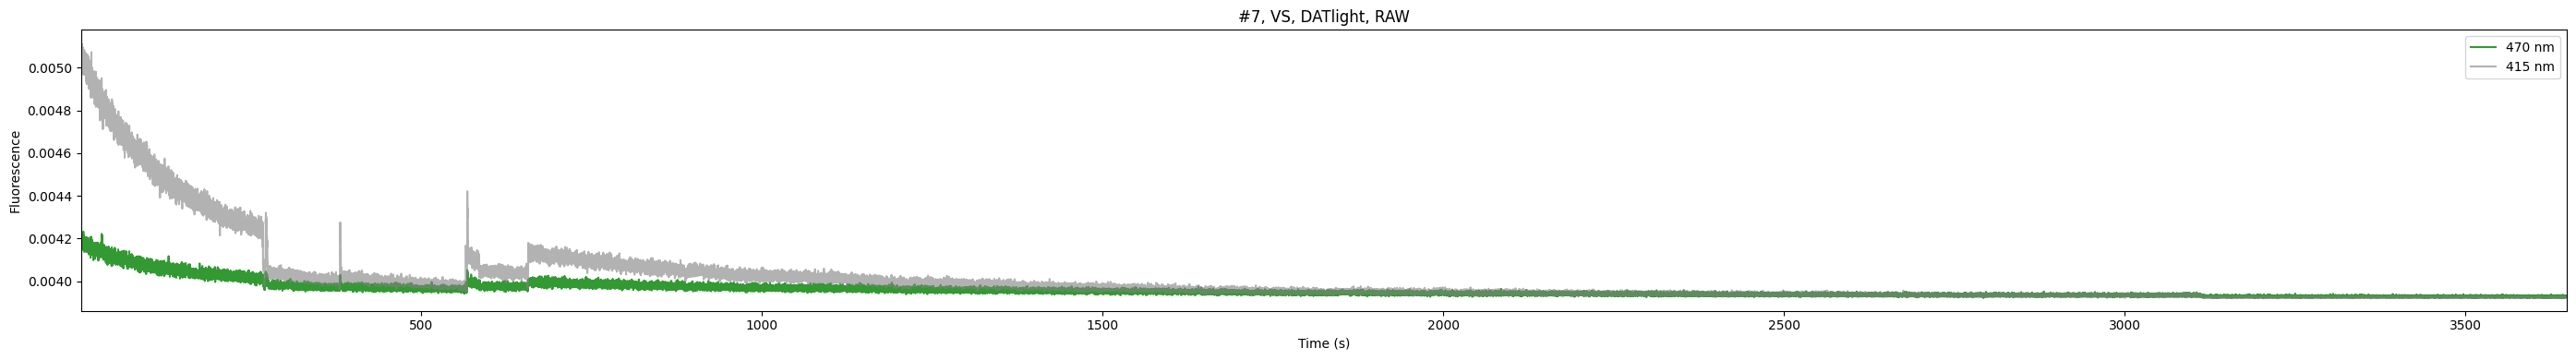

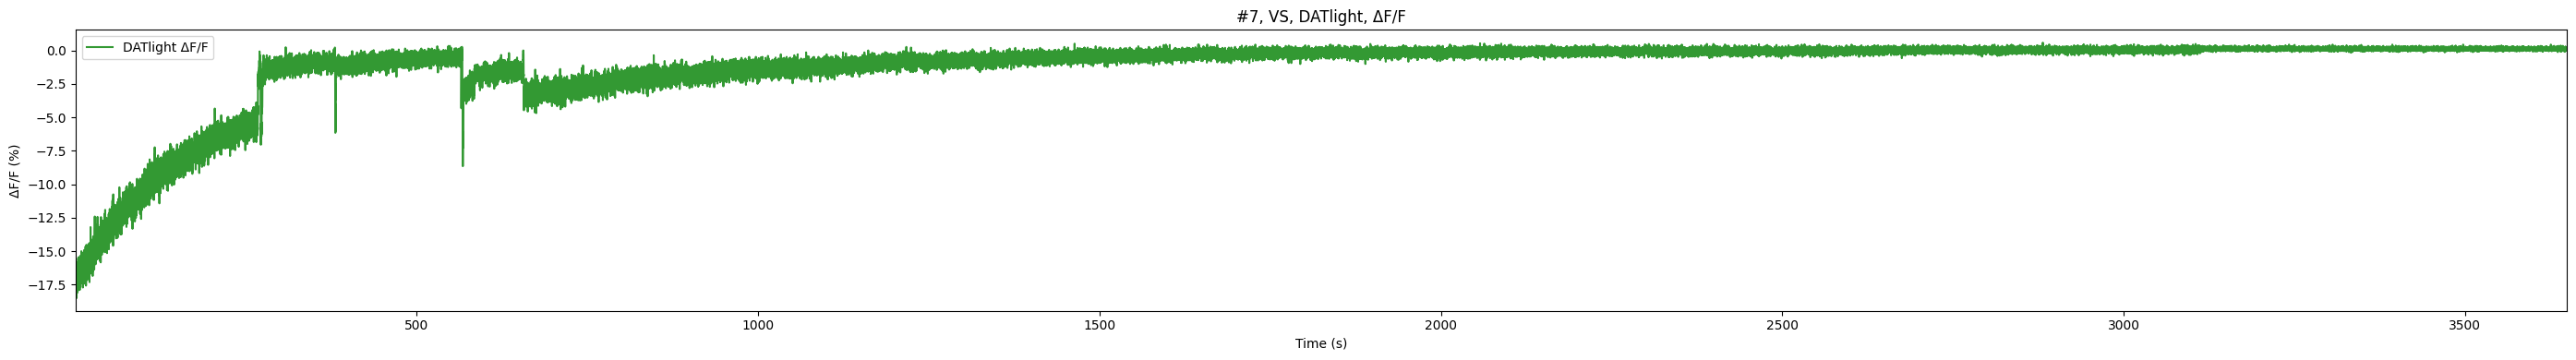

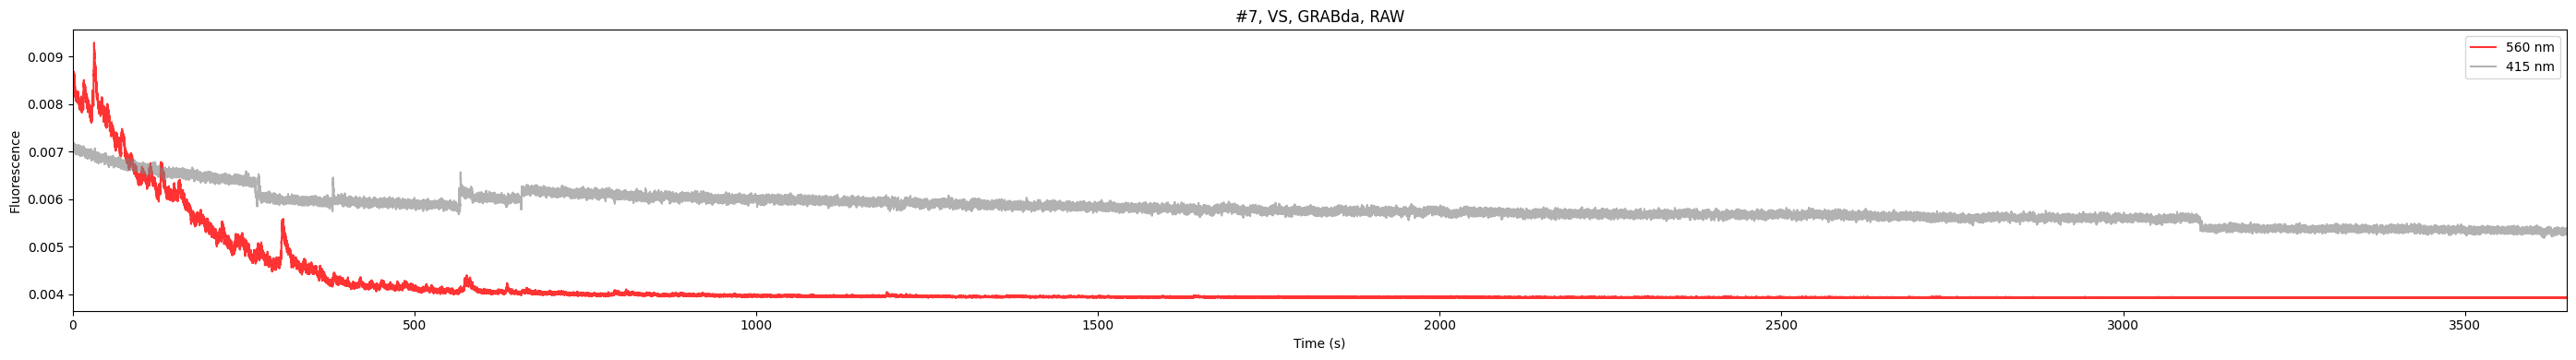

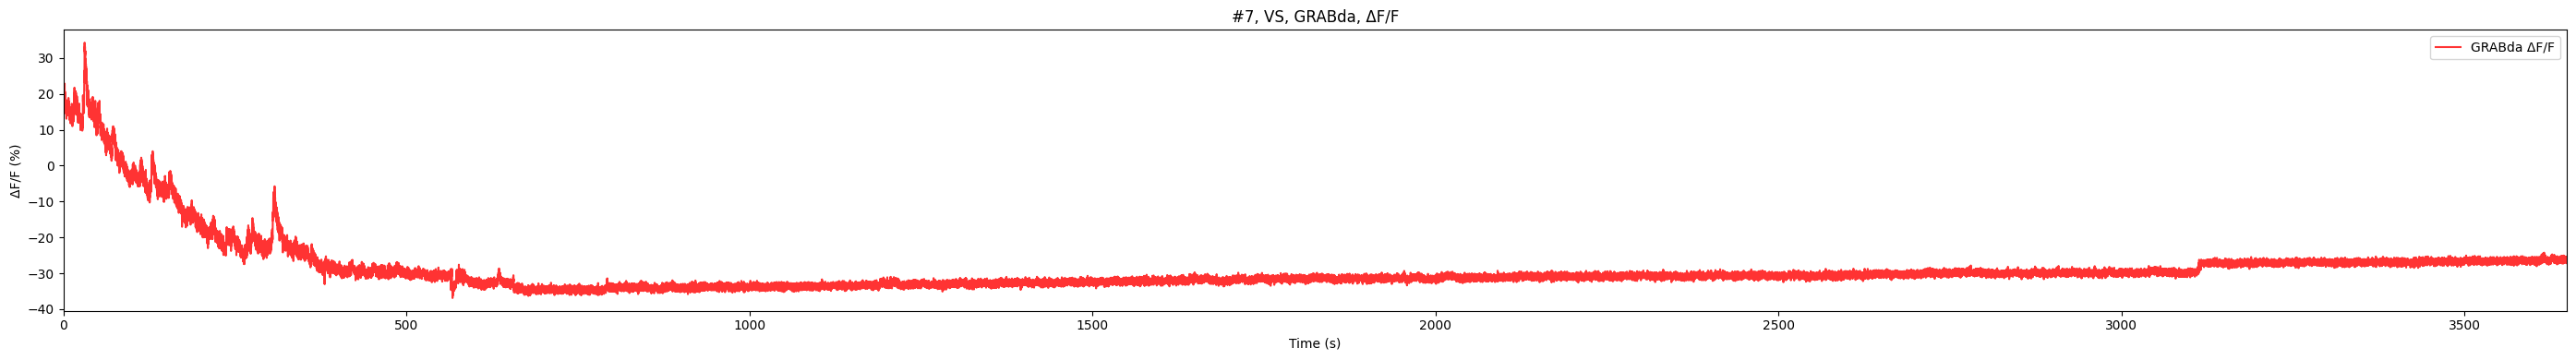

In [32]:
## DATA PROCESSING ##

main_folder = Path('/Users/gsw512/Documents/DATlight_P1.1_MGK')
subfolders = sorted([f.path for f in os.scandir(main_folder) if f.is_dir()])

# Set fiber configuration
fiber_config = {
    "3": {"VS": "G0"},
    "1": {"VS": "G4"},
    "5": {"VS": ["G0", "R1"]},
    "7": {"VS": ["G4", "R5"]}
}

# Sensor configuration
sensor_config = {
    "G": "DATlight",
    "R": "GRABda"
}

# Time stamp indexing for mice
timestamp_index = {
    0: [3, 5],
    1: [1, 7]
}

# Set excitation flags
L415 = 1
L470 = 2
L560 = 4

for subfolder in subfolders:
    exp_folder = os.path.basename(subfolder)

    timestamp_files = glob(os.path.join(subfolder, "Manual*.csv"))
    if timestamp_files:
        timestamp_file = timestamp_files[0]
        df_timestamps = pd.read_csv(timestamp_file)
    else:
        df_timestamps = None

    fp_files = glob(os.path.join(subfolder, "photo*.csv"))
    for fp_file in fp_files:
        df_fp = pd.read_csv(fp_file)
        
        animal_ids = [part for part in exp_folder.split("_") if part.isdigit()]
        for animal_id in animal_ids:
            if animal_id not in fiber_config:
                continue
            
            timestamps = 0
            if df_timestamps is not None:
                for idx, animals in timestamp_index.items():
                    if int(animal_id) in animals:
                        timestamps = df_timestamps.loc[idx, "FP3002_System_Timestamp"]
                        break
            
            df_fp["TimeCorrected"] = df_fp["SystemTimestamp"] - timestamps

            for brain_area, channels in fiber_config[animal_id].items():
                if isinstance(channels, str):
                    channels = [channels]

                for ch in channels:
                        
                    if ch.startswith("G"):
                        exc = df_fp.loc[df_fp["LedState"] == L470, ["TimeCorrected", ch]]
                        iso = df_fp.loc[df_fp["LedState"] == L415, ["TimeCorrected", ch]]
                        color = "green"
                        label_exc = "470 nm"
                        label_iso = "415 nm"
                            
                    elif ch.startswith("R"):
                        exc = df_fp.loc[df_fp["LedState"] == L560, ["TimeCorrected", ch]]
                        iso = df_fp.loc[df_fp["LedState"] == L415, ["TimeCorrected", ch]]
                        color = "red"
                        label_exc = "560 nm"
                        label_iso = "415 nm"

                    else:
                        continue
                    
                    exc = exc[exc["TimeCorrected"] >= 0]
                    iso = iso[iso["TimeCorrected"] >= 0]

                    sensor_name = sensor_config.get(ch[0], ch)
                    
                    # Plotting raw traces
                    plt.figure(figsize = (28,4))
                    plt.plot(exc["TimeCorrected"], exc[ch], color=color, alpha=0.8, label = label_exc)
                    plt.plot(iso["TimeCorrected"], iso[ch], color="gray", alpha= 0.6, label = label_iso)
                    plt.title(f"#{animal_id}, {brain_area}, {sensor_name}, RAW")
                    plt.xlim(exc["TimeCorrected"].min(), exc["TimeCorrected"].max())
                    plt.xlabel("Time (s)")
                    plt.ylabel("Fluorescence")
                    plt.legend()
                    plt.tight_layout()
                    plt.show()

                    # Normalize
                    sig     = exc[ch].values
                    ctrl    = iso[ch].values
                    min_len = min(len(sig), len(ctrl))
                    sig     = sig[:min_len]
                    ctrl    = ctrl[:min_len]
                    m, b        = np.polyfit(ctrl, sig, 1)
                    fitted      = m * ctrl + b
                    deltaF_F    = (sig - ctrl) / ctrl *100

                    # Plotting normalized traces
                    plt.figure(figsize=(28, 4))
                    plt.plot(exc["TimeCorrected"], deltaF_F, color=color, alpha=0.8, label=f"{sensor_name} ΔF/F")
                    plt.title(f"#{animal_id}, {brain_area}, {sensor_name}, ΔF/F")
                    plt.xlabel("Time (s)")
                    plt.ylabel("ΔF/F (%)")
                    plt.xlim(exc["TimeCorrected"].min(), exc["TimeCorrected"].max())
                    plt.legend()
                    plt.tight_layout()
                    plt.show()
                    


